# Reference Element Gallery

This notebook showcases the reference elements that form the building blocks of finite element analysis. Each reference element is defined on a standard domain (e.g., the unit triangle or unit square) and provides shape functions that are mapped to physical elements via Jacobian transformations.

In [1]:
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Math, display
from symbolic_fem_workbench.reference import (
    ReferenceTriangleP1, ReferenceQuadrilateralQ1, ReferenceQuadrilateralQ2,
    ReferenceTetrahedronP1, ReferenceTetrahedronP2, ReferenceHexahedronQ1,
)

## 2D Elements

### Triangle P1 (Linear Triangle)

In [2]:
xi, eta = sp.symbols("xi eta")
tri = ReferenceTriangleP1(xi, eta)

print("=== Triangle P1 ===")
print(f"Nodes: {tri.nodes}")
print(f"Number of nodes: {len(tri.nodes)}")
for i, N in enumerate(tri.shape_functions):
    display(Math(f"N_{{{i+1}}} = " + sp.latex(N)))
print(f"Partition of unity: {sp.simplify(sum(tri.shape_functions))}")

# Kronecker delta check
print("\nKronecker delta property (N_i(node_j) = delta_ij):")
for i, node in enumerate(tri.nodes):
    vals = [sp.simplify(N.subs({xi: node[0], eta: node[1]})) for N in tri.shape_functions]
    print(f"  N(node {i+1}) = {vals}")

=== Triangle P1 ===
Nodes: ((0, 0), (1, 0), (0, 1))
Number of nodes: 3


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Partition of unity: 1

Kronecker delta property (N_i(node_j) = delta_ij):
  N(node 1) = [1, 0, 0]
  N(node 2) = [0, 1, 0]
  N(node 3) = [0, 0, 1]


### Quadrilateral Q1 (Bilinear Quad)

In [3]:
quad1 = ReferenceQuadrilateralQ1(xi, eta)
print("=== Quadrilateral Q1 ===")
print(f"Nodes: {quad1.nodes}")
for i, N in enumerate(quad1.shape_functions):
    display(Math(f"N_{{{i+1}}} = " + sp.latex(N)))
print(f"Partition of unity: {sp.simplify(sum(quad1.shape_functions))}")

# Kronecker delta
print("\nKronecker delta property:")
for i, node in enumerate(quad1.nodes):
    vals = [sp.simplify(N.subs({xi: node[0], eta: node[1]})) for N in quad1.shape_functions]
    print(f"  N(node {i+1}) = {vals}")

=== Quadrilateral Q1 ===
Nodes: ((-1, -1), (1, -1), (1, 1), (-1, 1))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Partition of unity: 1

Kronecker delta property:
  N(node 1) = [1, 0, 0, 0]
  N(node 2) = [0, 1, 0, 0]
  N(node 3) = [0, 0, 1, 0]
  N(node 4) = [0, 0, 0, 1]


### Quadrilateral Q2 (Biquadratic Quad)

In [4]:
quad2 = ReferenceQuadrilateralQ2(xi, eta)
print("=== Quadrilateral Q2 ===")
print(f"Nodes: {quad2.nodes}")
print(f"Number of nodes: {len(quad2.nodes)}")
for i, N in enumerate(quad2.shape_functions):
    display(Math(f"N_{{{i+1}}} = " + sp.latex(sp.simplify(N))))

=== Quadrilateral Q2 ===
Nodes: ((-1, -1), (0, -1), (1, -1), (1, 0), (1, 1), (0, 1), (-1, 1), (-1, 0), (0, 0))
Number of nodes: 9


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 3D Elements

In [5]:
zeta = sp.Symbol("zeta")
tet1 = ReferenceTetrahedronP1(xi, eta, zeta)
tet2 = ReferenceTetrahedronP2(xi, eta, zeta)
hex1 = ReferenceHexahedronQ1(xi, eta, zeta)

for name, elem in [("Tet P1", tet1), ("Tet P2", tet2), ("Hex Q1", hex1)]:
    print(f"\n=== {name} ===")
    print(f"Number of nodes: {len(elem.nodes)}")
    print(f"Partition of unity: {sp.simplify(sum(elem.shape_functions))}")


=== Tet P1 ===
Number of nodes: 4
Partition of unity: 1

=== Tet P2 ===
Number of nodes: 10
Partition of unity: 1

=== Hex Q1 ===
Number of nodes: 8


Partition of unity: 1


## Visualizing 2D Shape Functions

We create contour plots of the P1 triangle shape functions on the reference element to visualize their linear nature.

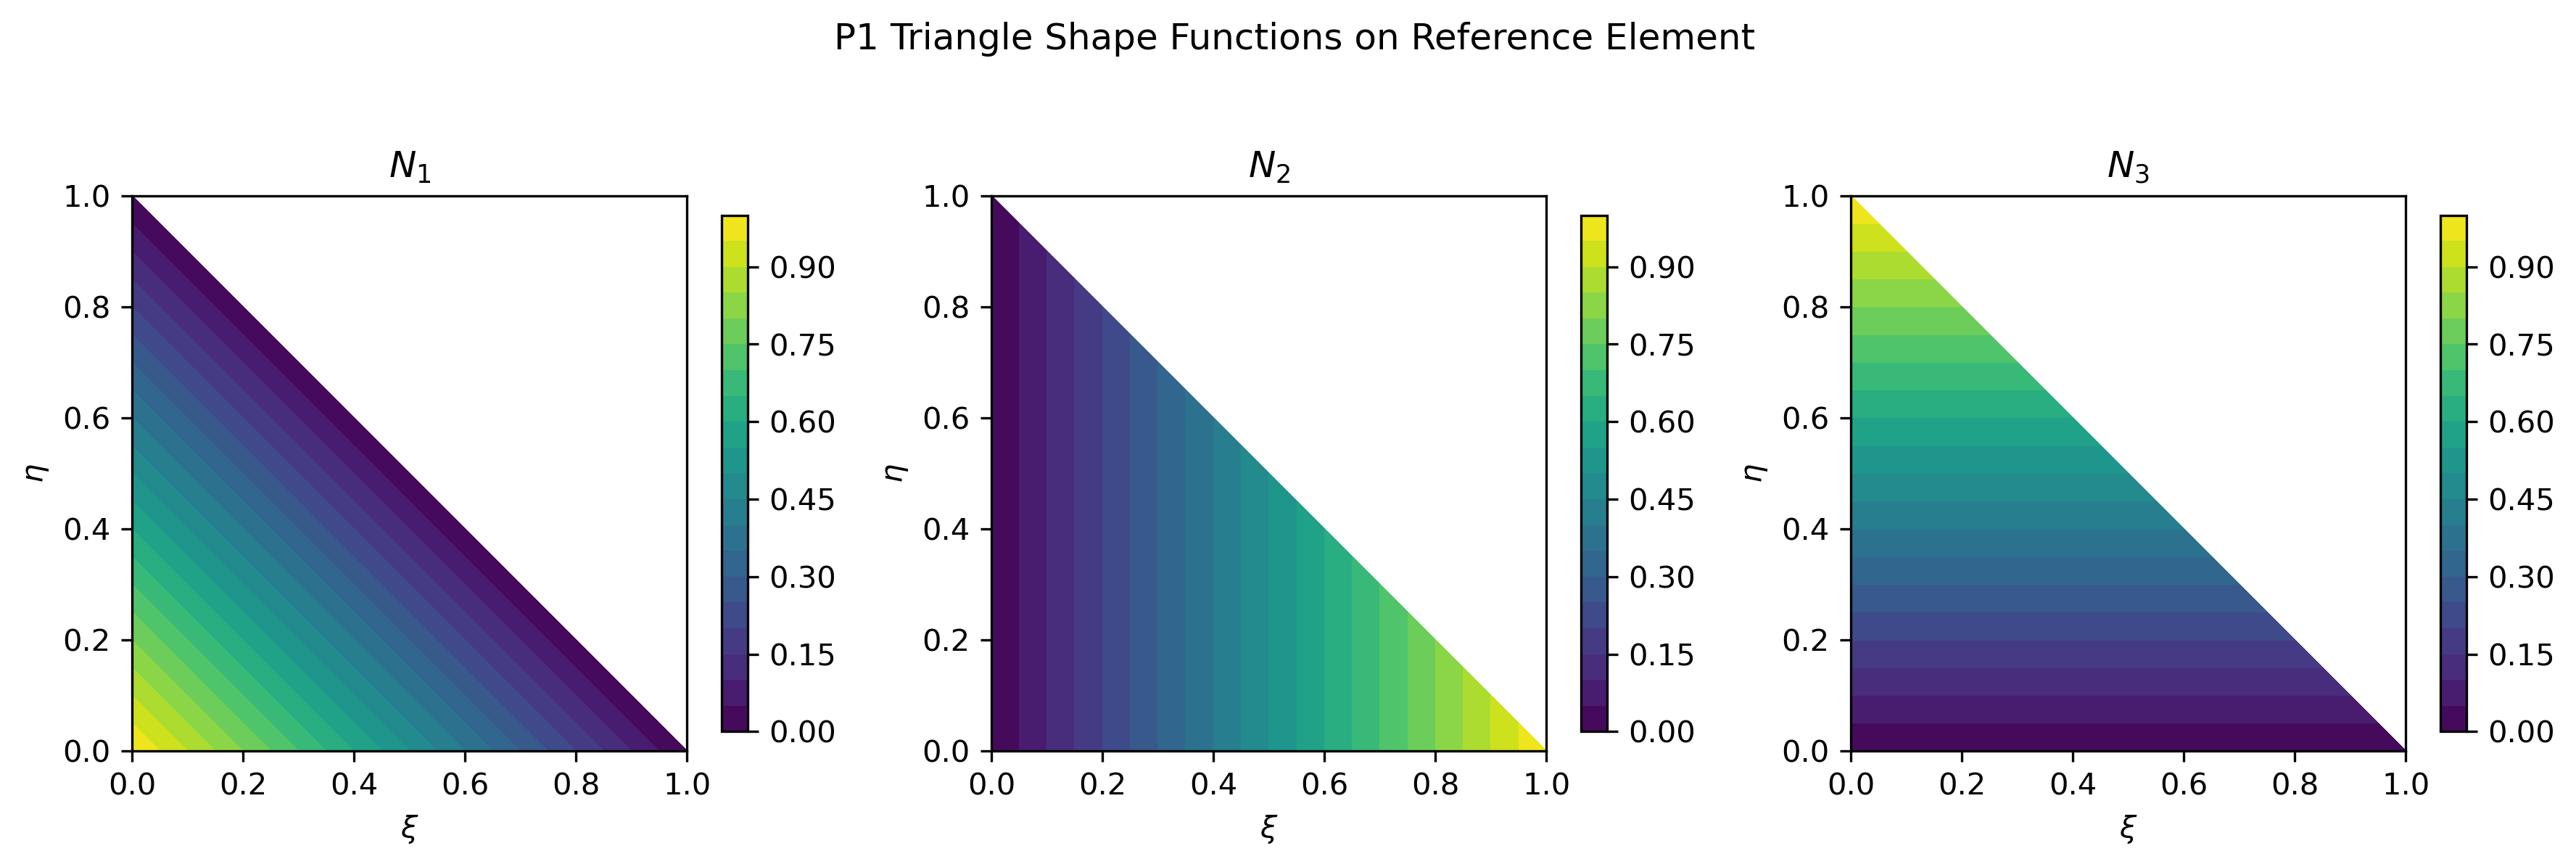

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
xi_vals = np.linspace(0, 1, 50)
eta_vals = np.linspace(0, 1, 50)
XI, ETA = np.meshgrid(xi_vals, eta_vals)
mask = XI + ETA <= 1.0

for idx, (ax, N_sym) in enumerate(zip(axes, tri.shape_functions)):
    N_fn = sp.lambdify((xi, eta), N_sym, "numpy")
    Z = N_fn(XI, ETA)
    Z = np.where(mask, Z, np.nan)
    c = ax.contourf(XI, ETA, Z, levels=20, cmap="viridis")
    ax.set_title(f"$N_{{{idx+1}}}$")
    ax.set_xlabel(r"$\xi$")
    ax.set_ylabel(r"$\eta$")
    ax.set_aspect("equal")
    plt.colorbar(c, ax=ax, shrink=0.7)

plt.suptitle("P1 Triangle Shape Functions on Reference Element")
plt.tight_layout()
plt.show()

## Visualizing Q1 Quadrilateral Shape Functions

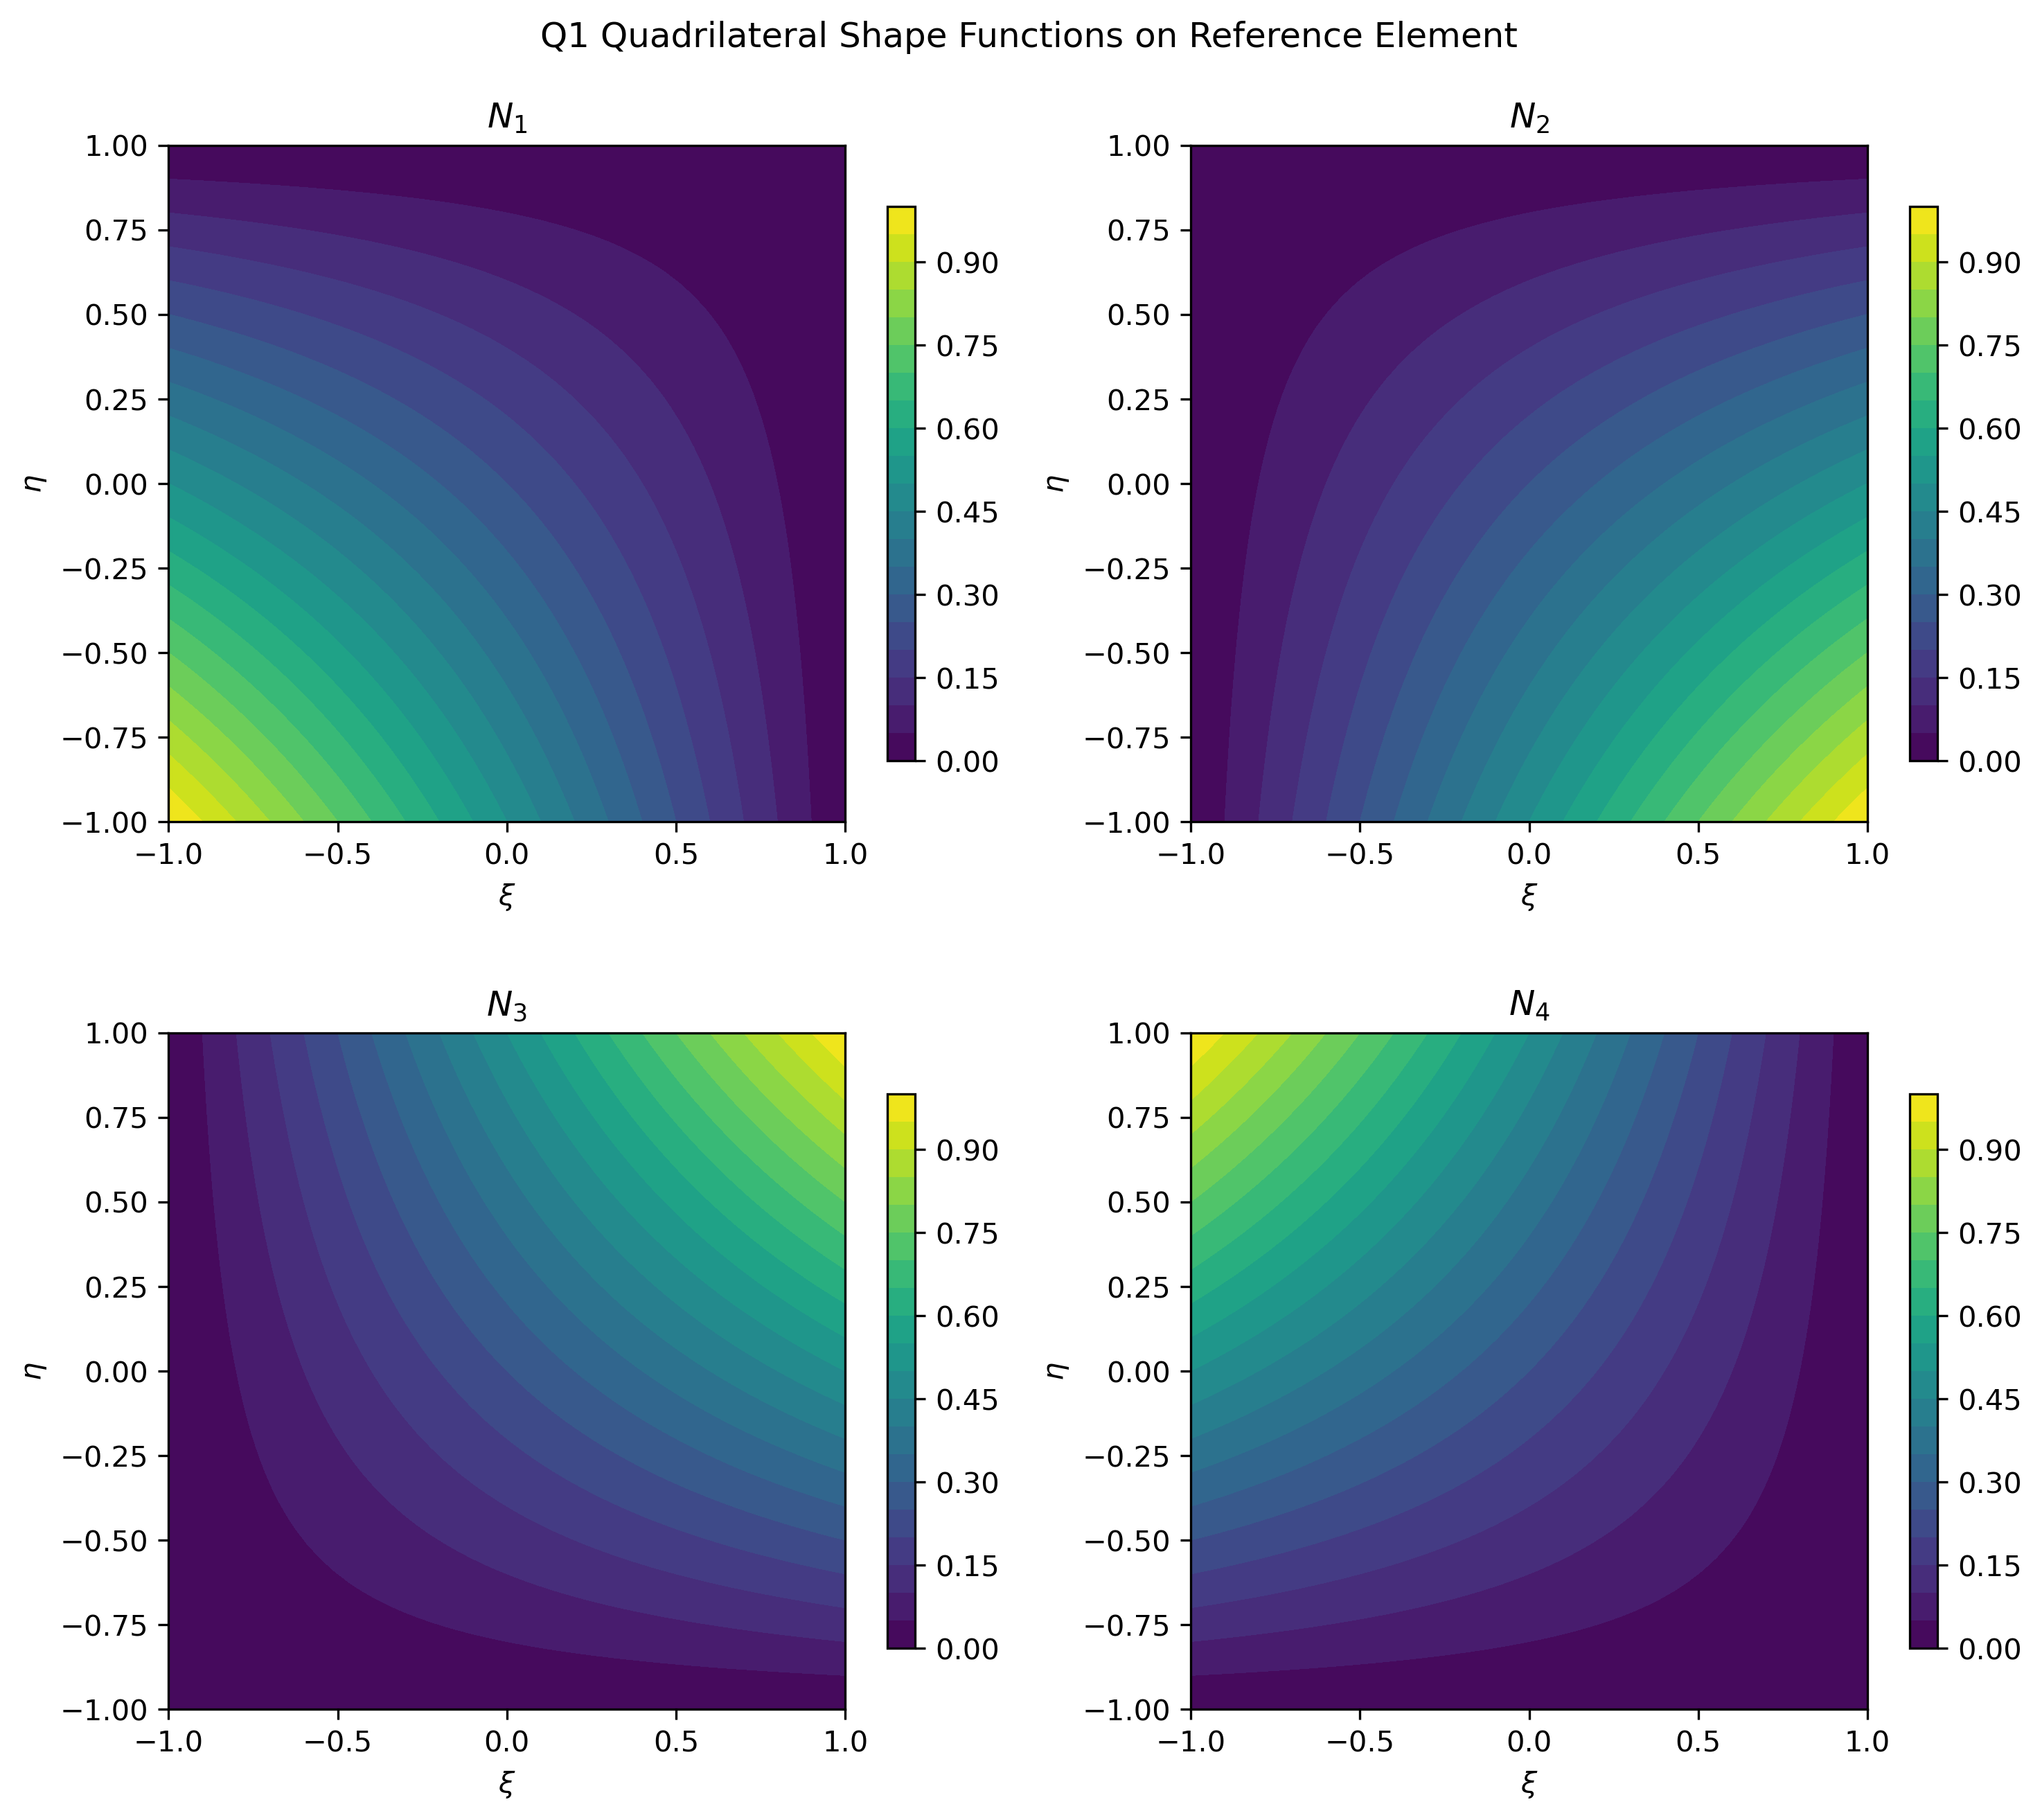

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.flatten()
xi_vals_q = np.linspace(-1, 1, 50)
eta_vals_q = np.linspace(-1, 1, 50)
XI_q, ETA_q = np.meshgrid(xi_vals_q, eta_vals_q)

for idx, (ax, N_sym) in enumerate(zip(axes, quad1.shape_functions)):
    N_fn = sp.lambdify((xi, eta), N_sym, "numpy")
    Z = N_fn(XI_q, ETA_q)
    c = ax.contourf(XI_q, ETA_q, Z, levels=20, cmap="viridis")
    ax.set_title(f"$N_{{{idx+1}}}$")
    ax.set_xlabel(r"$\xi$")
    ax.set_ylabel(r"$\eta$")
    ax.set_aspect("equal")
    plt.colorbar(c, ax=ax, shrink=0.7)

plt.suptitle("Q1 Quadrilateral Shape Functions on Reference Element")
plt.tight_layout()
plt.show()

## Exercise

**Question:** Verify the Kronecker delta property for the Q2 quadrilateral. For each node, evaluate all 9 shape functions and check that $N_i(\text{node}_j) = \delta_{ij}$. Which shape function is the most "localized" (has the smallest support)?

In [8]:
# Exercise: Verify the Kronecker delta property for the Q2 quadrilateral.
# For each node, evaluate all 9 shape functions and check N_i(node_j) = delta_ij.

